**REQUIRED LIBRARY IMPORTING AND LOADING DATA**

In [ ]:
# STEP 1: Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [ ]:
# STEP 2: Load Dataset
df = pd.read_csv("AI & ML Intern Dataset Task 3.csv")
df.head()

# STEP 3: Dataset Overview
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          500 non-null    int64  
 1   age                  460 non-null    float64
 2   gender               500 non-null    object 
 3   education_level      460 non-null    object 
 4   monthly_income       460 non-null    float64
 5   years_of_experience  500 non-null    int64  
 6   department           500 non-null    object 
 7   hours_per_week       460 non-null    float64
 8   performance_score    460 non-null    float64
 9   promotion            500 non-null    int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 39.2+ KB


,customer_id,age,monthly_income,years_of_experience,hours_per_week,performance_score,promotion
count,500.000000,460.000000,460.000000,500.000000,460.000000,460.000000,500.000000
mean,250.500000,41.471739,83572.146297,18.978000,39.810870,3.044654,0.472000
std,144.481833,13.403787,39166.719730,11.807131,11.681741,1.185564,0.499715
min,1.000000,18.000000,15434.615814,0.000000,20.000000,1.000000,0.000000
25%,125.750000,30.000000,50179.201842,9.000000,30.000000,1.965901,0.000000
50%,250.500000,43.000000,82448.644742,19.000000,40.000000,3.074559,0.000000
75%,375.250000,52.000000,117367.316575,30.000000,50.000000,4.062314,1.000000
max,500.000000,64.000000,159243.047096,41.000000,59.000000,5.000000,1.000000


**EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
# STEP 4: Handle Missing Values
num_cols = ['age', 'monthly_income', 'years_of_experience',
            'hours_per_week', 'performance_score']

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

cat_cols = ['gender', 'education_level', 'department']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# STEP 5: Encode Categorical Variables
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# STEP 6: Feature Selection
X = df.drop(['customer_id', 'promotion'], axis=1)
y = df['promotion']

# STEP 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 8: Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/tmp/ipython-input-3305654950.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-3305654950.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

**DATA PREPROCESSING**

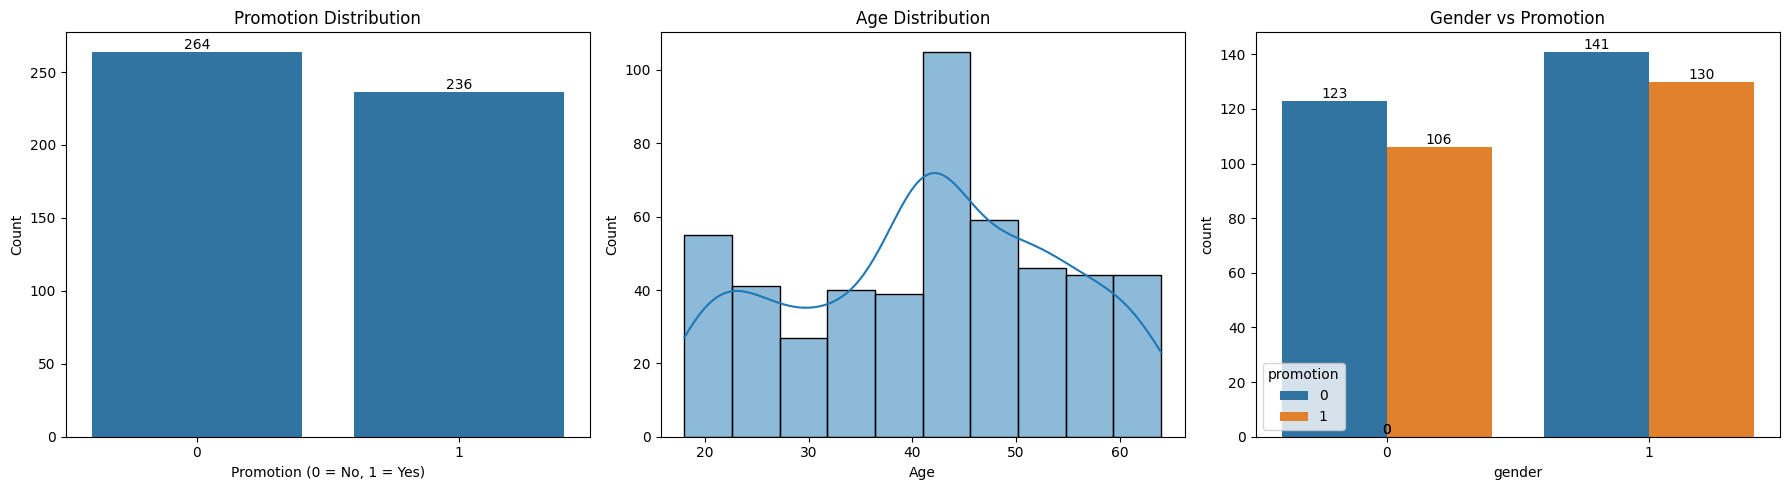

In [ ]:
plt.figure(figsize=(18,5))

# 1️⃣ Promotion Distribution
plt.subplot(1,3,1)
ax1 = sns.countplot(x='promotion', data=df)
plt.title("Promotion Distribution")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Count")
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom')

# 2️⃣ Age Distribution
plt.subplot(1,3,2)
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

# 3️⃣ Gender vs Promotion
plt.subplot(1,3,3)
ax3 = sns.countplot(x='gender', hue='promotion', data=df)
plt.title("Gender vs Promotion")
for p in ax3.patches:
    ax3.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


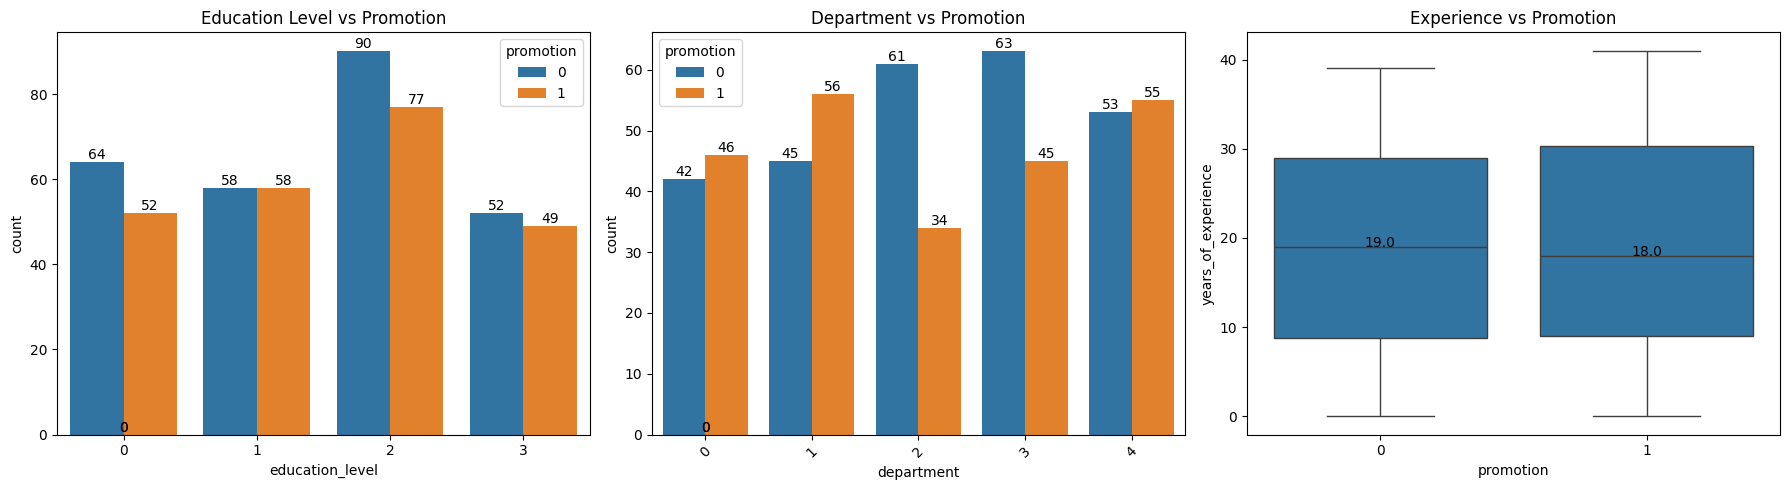

In [ ]:
plt.figure(figsize=(18,5))

# 4️⃣ Education Level vs Promotion
plt.subplot(1,3,1)
ax4 = sns.countplot(x='education_level', hue='promotion', data=df)
plt.title("Education Level vs Promotion")
for p in ax4.patches:
    ax4.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom')

# 5️⃣ Department vs Promotion
plt.subplot(1,3,2)
ax5 = sns.countplot(x='department', hue='promotion', data=df)
plt.title("Department vs Promotion")
plt.xticks(rotation=45)
for p in ax5.patches:
    ax5.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom')

# 6️⃣ Years of Experience vs Promotion
plt.subplot(1,3,3)
ax6 = sns.boxplot(x='promotion', y='years_of_experience', data=df)
plt.title("Experience vs Promotion")

# Median annotation
med_exp = df.groupby('promotion')['years_of_experience'].median()
for i, v in enumerate(med_exp):
    ax6.text(i, v, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()


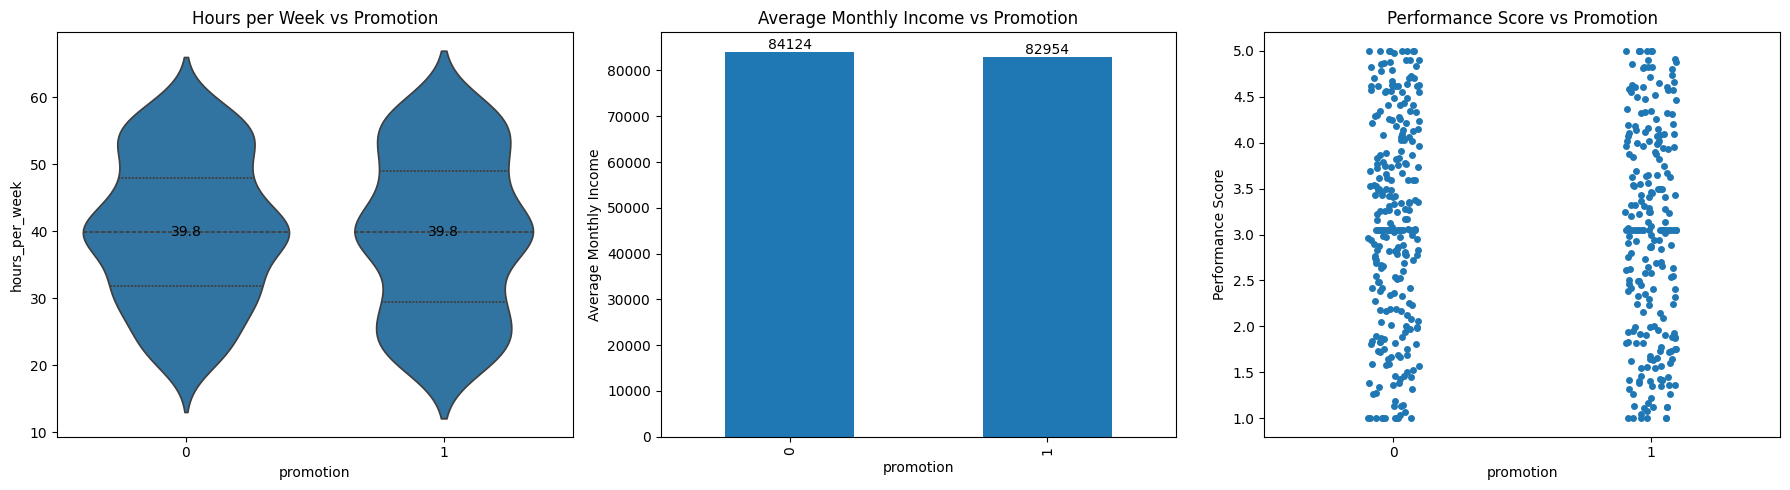

In [ ]:
plt.figure(figsize=(18,5))

# 7️⃣ Hours per Week vs Promotion → VIOLIN PLOT
plt.subplot(1,3,1)
ax7 = sns.violinplot(x='promotion', y='hours_per_week', data=df, inner='quartile')
plt.title("Hours per Week vs Promotion")

med_hours = df.groupby('promotion')['hours_per_week'].median()
for i, v in enumerate(med_hours):
    ax7.text(i, v, f'{v:.1f}', ha='center', va='center')

# 8️⃣ Monthly Income vs Promotion → BAR PLOT (Mean)
plt.subplot(1,3,2)
avg_income = df.groupby('promotion')['monthly_income'].mean()
ax8 = avg_income.plot(kind='bar')
plt.title("Average Monthly Income vs Promotion")
plt.ylabel("Average Monthly Income")

for i, v in enumerate(avg_income):
    ax8.text(i, v, f'{int(v)}', ha='center', va='bottom')

# 9️⃣ Performance Score vs Promotion → STRIP PLOT
plt.subplot(1,3,3)
ax9 = sns.stripplot(
    x='promotion',
    y='performance_score',
    data=df,
    jitter=True
)
plt.title("Performance Score vs Promotion")
plt.ylabel("Performance Score")

plt.tight_layout()
plt.show()


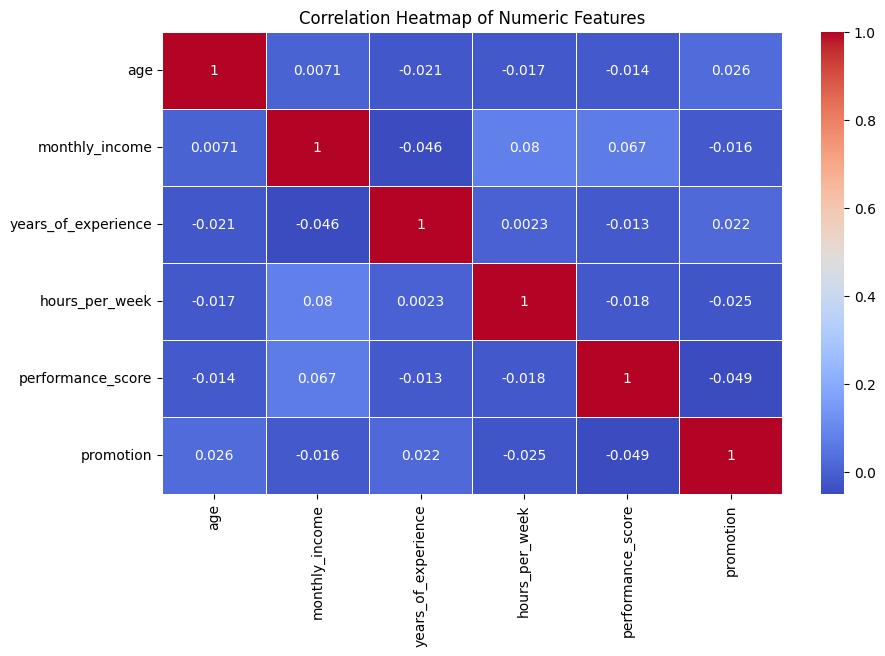

In [ ]:
# STEP 14: Correlation Heatmap (EDA)

numeric_df = df[['age', 'monthly_income', 'years_of_experience',
                 'hours_per_week', 'performance_score', 'promotion']]

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


**MODEL DEVELOPMENT (5 MODELS)**

In [ ]:
# STEP 15: Define Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

**MODEL EVALUATION & INSIGHTS**


 Logistic Regression
Accuracy: 0.49
              precision    recall  f1-score   support

           0       0.51      0.68      0.59        53
           1       0.43      0.28      0.34        47

    accuracy                           0.49       100
   macro avg       0.47      0.48      0.46       100
weighted avg       0.48      0.49      0.47       100


 Decision Tree
Accuracy: 0.42
              precision    recall  f1-score   support

           0       0.45      0.47      0.46        53
           1       0.38      0.36      0.37        47

    accuracy                           0.42       100
   macro avg       0.42      0.42      0.42       100
weighted avg       0.42      0.42      0.42       100


 Random Forest
Accuracy: 0.53
              precision    recall  f1-score   support

           0       0.55      0.68      0.61        53
           1       0.50      0.36      0.42        47

    accuracy                           0.53       100
   macro avg       0.52      

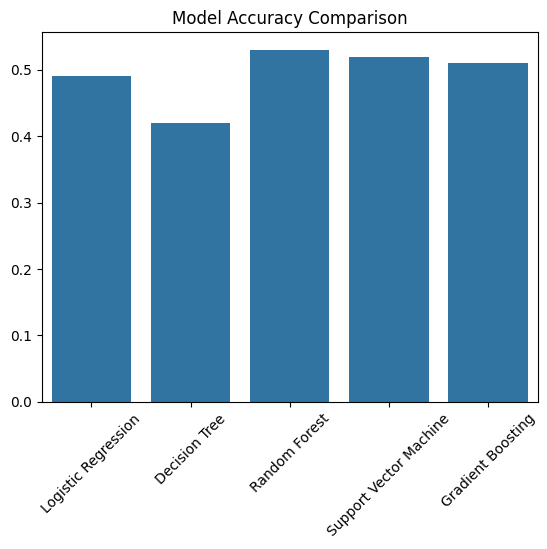


✅ Best Model Based on Accuracy
Model Name: Random Forest
Accuracy: 0.53


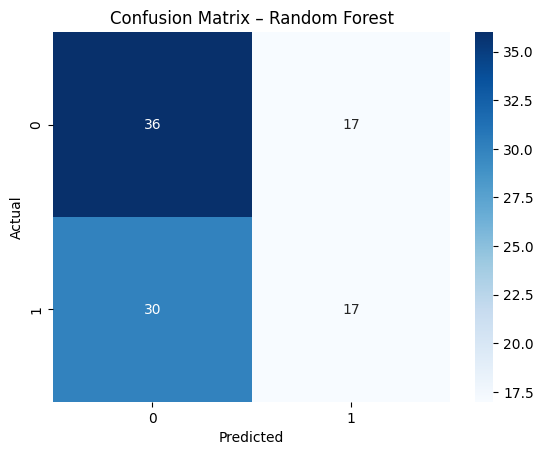

In [ ]:
# STEP 16: Store Accuracy
results = {}

best_acc = 0
best_model = None
best_model_name = ""

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

    print("\n", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

# STEP 17: Model Comparison Visualization
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

# STEP 18: Identify & Print Best Model
print("\n✅ Best Model Based on Accuracy")
print("Model Name:", best_model_name)
print("Accuracy:", best_acc)


# STEP 19: Confusion Matrix for the Best Model
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()

# STEP 20: Feature Importance
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    feature_importance
else:
    print(f"Feature importance not available for {best_model_name}")


In [ ]:
# STEP 21: Predict promotion outcomes using the best model
predictions = best_model.predict(X_test)

# Convert predictions to DataFrame
pred_df = pd.DataFrame(predictions, columns=['Predicted_Promotion'])

# Count predictions
counts = pred_df['Predicted_Promotion'].value_counts().sort_index()

# Convert counts to percentage
percentages = (counts / counts.sum()) * 100

# Map numeric labels to meaningful names
promotion_labels = counts.index.map({0: 'Not Promoted', 1: 'Promoted'})

# Final proportion table
proportion_df = pd.DataFrame({
    'Promotion_Status': promotion_labels,
    'Employee_Count': counts.values,
    'Percentage (%)': percentages.round(2).values
})

proportion_df

,Promotion_Status,Employee_Count,Percentage (%)
0,Not Promoted,66,66.0
1,Promoted,34,34.0
